In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# streamDaQ_file = "streamDaQExecutionResultsSliding.csv"
streamDaQ_file_sliding = "streamDaQExecutionResultsSliding.csv"
streamDaQ_file = "streamDaQExecutionResults2.csv"
deequ_file5 = "deequ 5.csv"
deequ_file10 = "deequ 10.csv"
deequ_file15 = "deequ 15.csv"
deequ_file20 = "deequ 20.csv"

MIN_COUNT = 1000
MAX_COUNT = 8000
LINEWIDTH = 1.5
LINESTYLE = '-'

SMOOTHING_FACTOR = 3
BIN_SIZE = 100


def read_preprocess_deequ(deequ_file:str, smooth: bool=False, tumbling: bool=False):
  # Load the metrics data for deequ
  deequ_df = pd.read_csv(deequ_file)

  # Process the data
  deequ_df['windowStart'] = pd.to_datetime(deequ_df['windowStart'])
  deequ_df['windowEnd'] = pd.to_datetime(deequ_df['windowEnd'])
  deequ_df['timestamp'] = pd.to_datetime(deequ_df['timestamp'])

  # Ensure numerical columns are the correct data type
  numerical_columns = ['batchId', 'batchSize', 'numChecks', 'executionTimeMs', 'checkingTimeMs']
  deequ_df[numerical_columns] = deequ_df[numerical_columns].apply(pd.to_numeric)
  deequ_df["throughput"] = deequ_df['batchSize'] / (deequ_df['executionTimeMs'])
  if smooth:
    deequ_df["throughput"] = deequ_df["throughput"].rolling(window=SMOOTHING_FACTOR, min_periods=1).mean()
  deequ_df = deequ_df.query(f'batchSize>{MIN_COUNT}').query(f'batchSize<={MAX_COUNT}')
  if tumbling:
    deequ_df['batchSize'] = (deequ_df['batchSize'] // BIN_SIZE) * BIN_SIZE # only for tumbling
  return deequ_df

def plot_deequ_throughput(deequ_file:str, label:str, color:str, smooth: bool=False, tumbling:bool=False):
  deequ_df = read_preprocess_deequ(deequ_file, smooth=smooth, tumbling=tumbling)

  # Group data by batchSize and calculate mean and standard deviation
  grouped = deequ_df.groupby('batchSize')['throughput'].agg(['mean', 'std']).reset_index()

  # Sort the grouped data by batchSize for plotting
  grouped = grouped.sort_values('batchSize')

  plt.plot(grouped['batchSize'], grouped['mean'], linewidth=LINEWIDTH, color=color, label=label, linestyle=LINESTYLE)


def read_preprocess_stream_daq(stream_daq_file:str, smooth: bool=False, tumbling: bool=False):
  streamDaQ_data = pd.read_csv(stream_daq_file)

  streamDaQ_data["executionTimeMs"] = streamDaQ_data["time"] - streamDaQ_data["window_end"]
  streamDaQ_data["throughput"] = streamDaQ_data['count'] / (streamDaQ_data['executionTimeMs']/1000)
  if smooth:
    streamDaQ_data["throughput"] = streamDaQ_data["throughput"].rolling(window=SMOOTHING_FACTOR, min_periods=1).mean()
  streamDaQ_data = streamDaQ_data.query(f'count>{MIN_COUNT}').query(f'count<={MAX_COUNT}')
  if tumbling:
    streamDaQ_data['count'] = (streamDaQ_data['count'] // BIN_SIZE) * BIN_SIZE # only for tumbling

  return streamDaQ_data


def plot_stream_daq_throughput(stream_daq_file: str, label:str, color:str, smooth: bool=False, tumbling:bool=False):
  streamDaQ_data = read_preprocess_stream_daq(stream_daq_file, smooth=smooth, tumbling=tumbling)
  grouped_daq = streamDaQ_data.groupby("count")["throughput"].agg(["mean", "std"]).reset_index()
  grouped_daq = grouped_daq.sort_values("count")
  plt.plot(grouped_daq['count'], grouped_daq['mean'], linewidth=LINEWIDTH, color=color, label=label, linestyle=LINESTYLE)

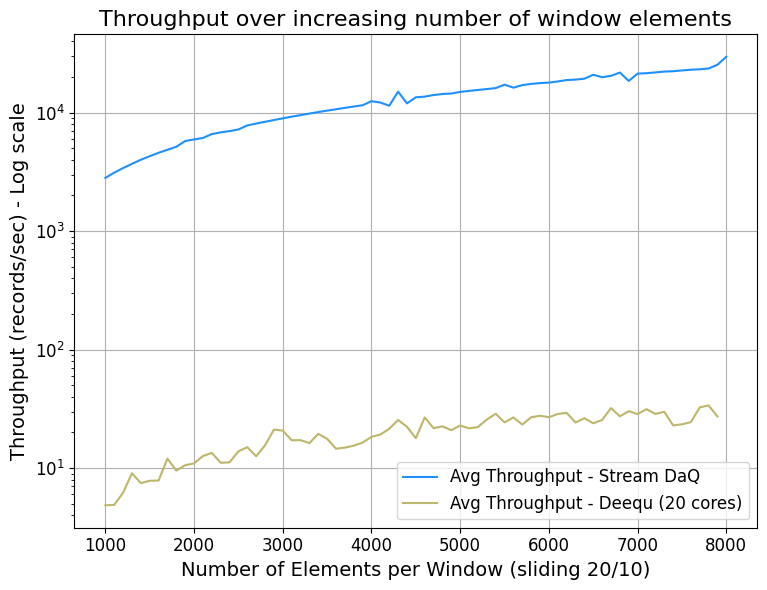

In [ ]:
# Plot Deequ (all cores) + Stream DaQ for tumbling 20sec


# Plotting
plt.figure(figsize=(8, 6))
plot_stream_daq_throughput(streamDaQ_file, "Avg Throughput - Stream DaQ", "dodgerblue", smooth=True, tumbling=True)
plot_deequ_throughput('deequ_increasing_elements_2.csv', "Avg Throughput - Deequ (20 cores)", "darkkhaki", smooth=True, tumbling=True)
# Customize plot
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Number of Elements per Window (sliding 20/10)', fontsize=14)
plt.ylabel('Throughput (records/sec) - Log scale', fontsize=14)
plt.title('Throughput over increasing number of window elements', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.yscale('log')
plt.savefig('throughput_tumbling.eps', format='eps', dpi=1000)
plt.show()

[512.6582278481012, 1090.9090909090908]


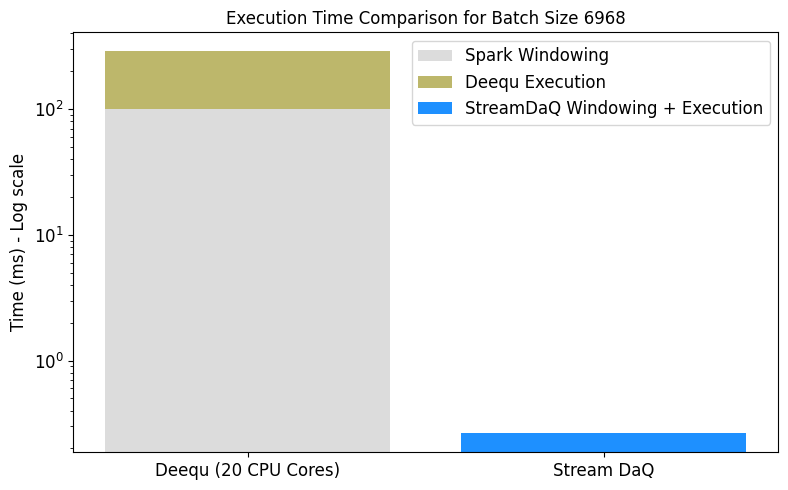

,batchSize,executionTimeMs1,checkingTimeMs,count,executionTimeMs2,difference
0,6072,648,174,6072,1.264,646.736
1,6968,288,187,6968,0.264,287.736


In [ ]:
deequ_df = read_preprocess_deequ(deequ_file20)
daq_df = read_preprocess_stream_daq(streamDaQ_file_sliding)

merged_df = pd.merge(
    deequ_df[['batchSize', 'executionTimeMs', 'checkingTimeMs']],
    daq_df[['count', 'executionTimeMs']],
    left_on='batchSize',
    right_on='count',
    suffixes=('1', '2')
)

merged_df["executionTimeMs2"] = merged_df["executionTimeMs2"]/1000

merged_df['difference'] = merged_df["executionTimeMs1"] - merged_df["executionTimeMs2"]

min_diff_row = merged_df.loc[merged_df['difference'].idxmin()]

print(list(merged_df['executionTimeMs1'] / merged_df['executionTimeMs2']))

# Extract values for plotting
batch_size = min_diff_row['batchSize']
execution_time1 = min_diff_row['executionTimeMs1']
check_time1 = min_diff_row['checkingTimeMs']
execution_time2 = min_diff_row['executionTimeMs2']

# Calculate windowing time
windowing_time1 = execution_time1 - check_time1

# Plotting
plt.figure(figsize=(8, 5))

# Stacked bar for System 1
plt.bar('Deequ (20 CPU Cores)', windowing_time1, label='Spark Windowing', color='gainsboro')
plt.bar('Deequ (20 CPU Cores)', check_time1, bottom=windowing_time1, label='Deequ Execution', color='darkkhaki')

# Bar for System 2
plt.bar('Stream DaQ', execution_time2, label='StreamDaQ Windowing + Execution', color='dodgerblue')


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('Time (ms) - Log scale', fontsize=12)
plt.title(f'(a) Execution Time Comparison for Batch Size {int(batch_size)}')
plt.tight_layout()
plt.yscale('log')
plt.legend(fontsize=12)
plt.savefig('bar_plot_execution.eps', format='eps', dpi=1000)
plt.show()

merged_df.head(20)

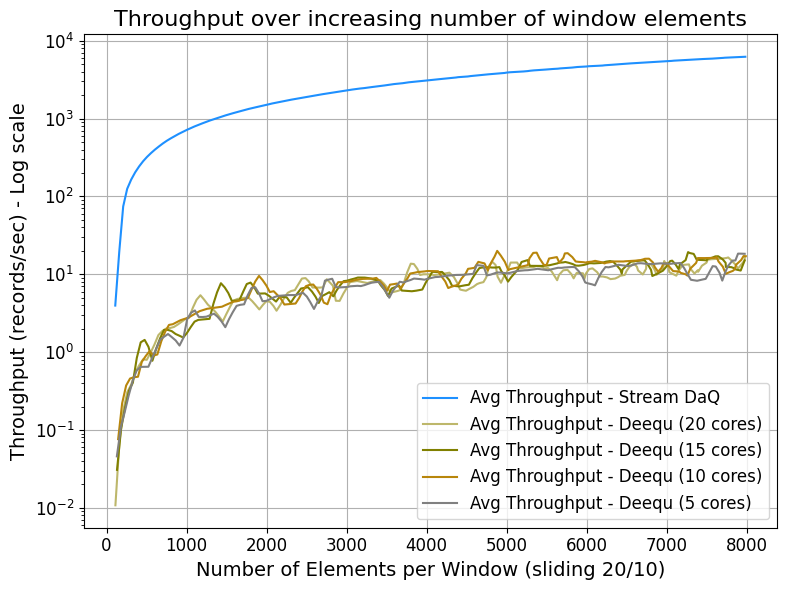

In [ ]:
# Plot Deequ (x4 variants) + Stream DaQ for sliding 20sec duration, 10sec slide


# Plotting
plt.figure(figsize=(8, 6))
plot_stream_daq_throughput(streamDaQ_file_sliding, "Avg Throughput - Stream DaQ", "dodgerblue")
plot_deequ_throughput(deequ_file20, "Avg Throughput - Deequ (20 cores)", "darkkhaki")
plot_deequ_throughput(deequ_file15, "Avg Throughput - Deequ (15 cores)", "olive")
plot_deequ_throughput(deequ_file10, "Avg Throughput - Deequ (10 cores)", "darkgoldenrod")
plot_deequ_throughput(deequ_file5, "Avg Throughput - Deequ (5 cores)", "grey")
# Customize plot
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Number of Elements per Window (sliding 20/10)', fontsize=14)
plt.ylabel('Throughput (records/sec) - Log scale', fontsize=14)
plt.title('Throughput over increasing number of window elements', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.yscale('log')
plt.savefig('throughput_sliding_all.eps', format='eps', dpi=1000)
plt.show()

[512.6582278481012, 1090.9090909090908]


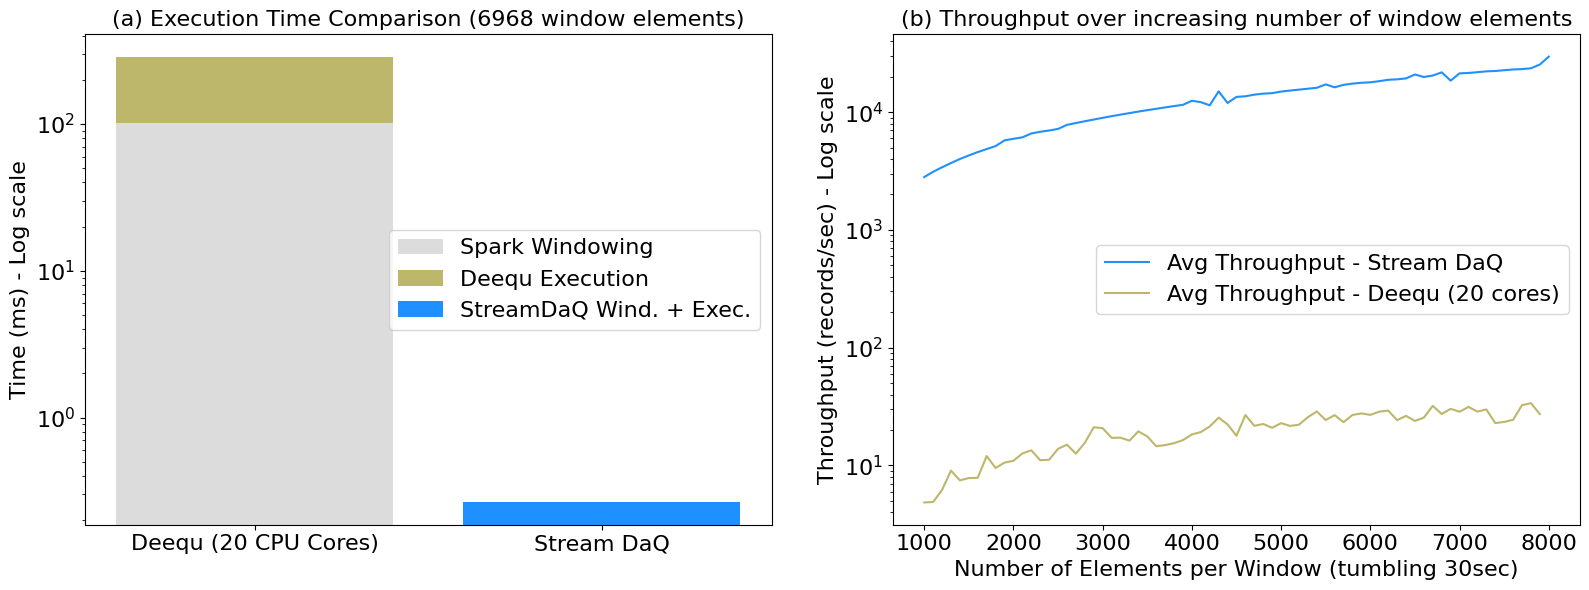

In [ ]:
FONT_SIZE = 16

deequ_df = read_preprocess_deequ(deequ_file20)
daq_df = read_preprocess_stream_daq(streamDaQ_file_sliding)

merged_df = pd.merge(
    deequ_df[['batchSize', 'executionTimeMs', 'checkingTimeMs']],
    daq_df[['count', 'executionTimeMs']],
    left_on='batchSize',
    right_on='count',
    suffixes=('1', '2')
)

merged_df["executionTimeMs2"] = merged_df["executionTimeMs2"]/1000

merged_df['difference'] = merged_df["executionTimeMs1"] - merged_df["executionTimeMs2"]

min_diff_row = merged_df.loc[merged_df['difference'].idxmin()]

print(list(merged_df['executionTimeMs1'] / merged_df['executionTimeMs2']))

# Extract values for plotting
batch_size = min_diff_row['batchSize']
execution_time1 = min_diff_row['executionTimeMs1']
check_time1 = min_diff_row['checkingTimeMs']
execution_time2 = min_diff_row['executionTimeMs2']

# Calculate windowing time
windowing_time1 = execution_time1 - check_time1

# Plotting
plt.figure(figsize=(16, 6))

# Left subplot
plt.subplot(1, 2, 1)



# Stacked bar for System 1
plt.bar('Deequ (20 CPU Cores)', windowing_time1, label='Spark Windowing', color='gainsboro')
plt.bar('Deequ (20 CPU Cores)', check_time1, bottom=windowing_time1, label='Deequ Execution', color='darkkhaki')

# Bar for System 2
plt.bar('Stream DaQ', execution_time2, label='StreamDaQ Wind. + Exec.', color='dodgerblue')
plt.title(f'(a) Execution Time Comparison ({int(batch_size)} window elements)', fontsize=FONT_SIZE)

plt.xticks(fontsize=FONT_SIZE)
plt.yticks(fontsize=FONT_SIZE)
plt.ylabel('Time (ms) - Log scale', fontsize=FONT_SIZE)
plt.yscale('log')
plt.legend(fontsize=FONT_SIZE)
plt.tight_layout()

# Right subplot
plt.subplot(1, 2, 2)
plot_stream_daq_throughput(streamDaQ_file, "Avg Throughput - Stream DaQ", "dodgerblue", smooth=True, tumbling=True)
plot_deequ_throughput('deequ_increasing_elements_2.csv', "Avg Throughput - Deequ (20 cores)", "darkkhaki", smooth=True, tumbling=True)
plt.title('(b) Throughput over increasing number of window elements', fontsize=FONT_SIZE)

# Customize plot
# plt.grid(True)
plt.xticks(fontsize=FONT_SIZE)
plt.yticks(fontsize=FONT_SIZE)
plt.xlabel('Number of Elements per Window (tumbling 30sec)', fontsize=FONT_SIZE)
plt.ylabel('Throughput (records/sec) - Log scale', fontsize=FONT_SIZE)
plt.legend(fontsize=FONT_SIZE)
plt.tight_layout()
plt.yscale('log')
plt.savefig('execution_time_throughput_tumbling.eps', format='eps', dpi=1000)
plt.show()

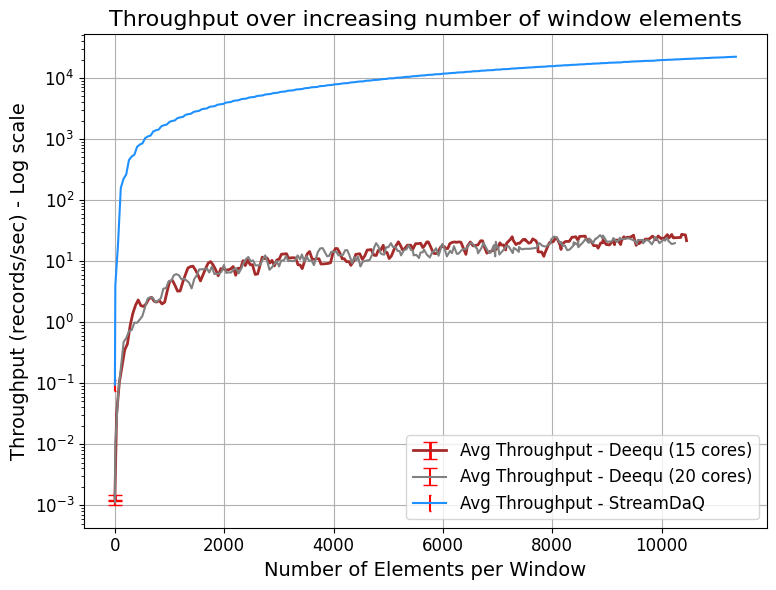

In [ ]:
# Load the metrics data for deequ
deequ_df = pd.read_csv(deequ_file)

# Process the data
deequ_df['windowStart'] = pd.to_datetime(deequ_df['windowStart'])
deequ_df['windowEnd'] = pd.to_datetime(deequ_df['windowEnd'])
deequ_df['timestamp'] = pd.to_datetime(deequ_df['timestamp'])

# Ensure numerical columns are the correct data type
numerical_columns = ['batchId', 'batchSize', 'numChecks', 'executionTimeMs', 'checkingTimeMs']
deequ_df[numerical_columns] = deequ_df[numerical_columns].apply(pd.to_numeric)
deequ_df["throughput"] = deequ_df['batchSize'] / (deequ_df['executionTimeMs'])
deequ_df["throughput"] = deequ_df["throughput"].rolling(window=3, min_periods=1).mean()

# Group data by batchSize and calculate mean and standard deviation
grouped = deequ_df.groupby('batchSize')['throughput'].agg(['mean', 'std']).reset_index()

# Sort the grouped data by batchSize for plotting
grouped = grouped.sort_values('batchSize')

# Plotting
plt.figure(figsize=(8, 6))

# Plot mean execution time with error bars representing standard deviation
plt.errorbar(grouped['batchSize'], grouped['mean'], yerr=grouped['std'], fmt='-', ecolor='red',
             capsize=5, label='Avg Throughput - Deequ (15 cores)', linewidth=2, color="brown")

###############################
# Load the metrics data for deequ
deequ_df = pd.read_csv(deequ_file2)

# Process the data
deequ_df['windowStart'] = pd.to_datetime(deequ_df['windowStart'])
deequ_df['windowEnd'] = pd.to_datetime(deequ_df['windowEnd'])
deequ_df['timestamp'] = pd.to_datetime(deequ_df['timestamp'])

# Ensure numerical columns are the correct data type
numerical_columns = ['batchId', 'batchSize', 'numChecks', 'executionTimeMs', 'checkingTimeMs']
deequ_df[numerical_columns] = deequ_df[numerical_columns].apply(pd.to_numeric)
deequ_df["throughput"] = deequ_df['batchSize'] / (deequ_df['executionTimeMs'])
deequ_df["throughput"] = deequ_df["throughput"].rolling(window=3, min_periods=1).mean()

# Group data by batchSize and calculate mean and standard deviation
grouped = deequ_df.groupby('batchSize')['throughput'].agg(['mean', 'std']).reset_index()

# Sort the grouped data by batchSize for plotting
grouped = grouped.sort_values('batchSize')

# Plot mean execution time with error bars representing standard deviation
plt.errorbar(grouped['batchSize'], grouped['mean'], yerr=grouped['std'], fmt='-', ecolor='red',
             capsize=5, label='Avg Throughput - Deequ (20 cores)', linewidth=1.5, color="gray")




########################
streamDaQ_data = pd.read_csv(streamDaQ_file)

streamDaQ_data["executionTimeMs"] = streamDaQ_data["time"] - streamDaQ_data["window_end"]
streamDaQ_data["throughput"] = streamDaQ_data['count'] / (streamDaQ_data['executionTimeMs']/1000)
streamDaQ_data["throughput"] = streamDaQ_data["throughput"].rolling(window=3, min_periods=1).mean()
# streamDaQ_data.head()

grouped_daq = streamDaQ_data.groupby("count")["throughput"].agg(["mean", "std"]).reset_index()
grouped_daq = grouped_daq.sort_values("count")
plt.errorbar(grouped_daq['count'], grouped_daq['mean'], yerr=grouped_daq['std'], fmt='-', linewidth=1.5, ecolor='red',
             capsize=1, label='Avg Throughput - StreamDaQ', color='dodgerblue')


# Customize plot
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Number of Elements per Window', fontsize=14)
plt.ylabel('Throughput (records/sec) - Log scale', fontsize=14)
plt.title('Throughput over increasing number of window elements', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.yscale('log')
plt.show()